![MuJoCo banner](https://raw.githubusercontent.com/google-deepmind/mujoco/main/banner.png)







### Copyright notice

> <p><small><small>Copyright 2025 DeepMind Technologies Limited.</small></p>
> <p><small><small>Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at <a href="http://www.apache.org/licenses/LICENSE-2.0">http://www.apache.org/licenses/LICENSE-2.0</a>.</small></small></p>
> <p><small><small>Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.</small></small></p>

# Locomotion in The Playground! <a href="https://colab.research.google.com/github/google-deepmind/mujoco_playground/blob/main/learning/notebooks/locomotion.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" width="140" align="center"/></a>

In this notebook, we'll walk through a few locomotion environments available in MuJoCo Playground.

**A Colab runtime with GPU acceleration is required.** If you're using a CPU-only runtime, you can switch using the menu "Runtime > Change runtime type".


In [1]:
# @title Check if MuJoCo installation was successful

import distutils.util
import os
import subprocess



# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl
import mujoco


# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl


In [2]:
# @title Import packages for plotting and creating graphics
import json
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

# Graphics and plotting.

import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

In [3]:
# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

In [4]:
#@title Import The Playground

from mujoco_playground import wrapper
from mujoco_playground import registry

# Locomotion

MuJoCo Playground contains a host of quadrupedal and bipedal environments (all listed below after running the command).

In [5]:
registry.locomotion.ALL_ENVS # Eigenese Environment müsste hinzugefügt/importiert werden.

('BarkourJoystick',
 'BerkeleyHumanoidJoystickFlatTerrain',
 'BerkeleyHumanoidJoystickRoughTerrain',
 'G1JoystickFlatTerrain',
 'G1JoystickRoughTerrain',
 'Go1JoystickFlatTerrain',
 'Go1JoystickRoughTerrain',
 'Go1Getup',
 'Go1Handstand',
 'Go1Footstand',
 'H1InplaceGaitTracking',
 'H1JoystickGaitTracking',
 'Op3Joystick',
 'SpotFlatTerrainJoystick',
 'SpotGetup',
 'SpotJoystickGaitTracking',
 'T1JoystickFlatTerrain',
 'T1JoystickRoughTerrain',
 'WolfgangJoystick')

# Bipedal

MuJoCo Playground also comes with a host of bipedal environments, such as the Berkely Humanoid and the Unitree G1/H1. Let's demonstrate a joystick policy on the Berkeley Humanoid. The initial policy takes 17 minutes to train on an RTX 4090.

In [6]:
from mujoco_playground.config import locomotion_params # locomotion_params.py für Wolfgang anpassen
from mujoco_playground._src.gait import draw_joystick_command # Übernehmbar? -> Visualisiert Joystick-Befehl als Pfeil
# env_name = 'BerkeleyHumanoidJoystickFlatTerrain'
env_name = 'WolfgangJoystick'
ppo_params = locomotion_params.brax_ppo_config(env_name) # Eigene Brax PPO Konfiguration -> Default Konfiguration nutzen? (siehe Kommentar oben)
# Über locomotion.register_environment das Environment für Wolfgang registrieren
env = registry.load(env_name) # Nutzbar, wenn Environment registriert ist
env_cfg = registry.get_default_config(env_name) # Nutzbar, wenn Environment registriert ist
# ppo_params = locomotion_params.brax_ppo_config(env_name)

In [7]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]

randomizer = registry.get_domain_randomizer(env_name) # randomize.py für Wolfgang erstellen
ppo_training_params = dict(ppo_params) # Zweck? -> Wahrscheinlich übernehmbar
network_factory = ppo_networks.make_ppo_networks # Netzwerk-Factory für PPO -> Referenz
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"] # Wird gelöscht, da "network_factory" kein direktes Argument für ppo.train ist. Es muss seperat übergeben werden (hier als network_factory) (siehe unten)
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      **ppo_params.network_factory
  )


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())


randomizer = registry.get_domain_randomizer(env_name) # Eigener Randomizer
ppo_training_params = dict(ppo_params) # Wozu das dict? 
network_factory = ppo_networks.make_ppo_networks # Evtl. übernehmbar? -> Genauer analysieren
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"]
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      **ppo_params.network_factory
  )


train_fn = functools.partial(
    ppo.train, **dict(ppo_training_params), # ppo.training sollte so übernehmbar sein
    network_factory=network_factory,
    randomization_fn=randomizer,
    progress_fn=progress
)

Env 'WolfgangJoystick' does not have a domain randomizer in the locomotion registry.
Env 'WolfgangJoystick' does not have a domain randomizer in the locomotion registry.


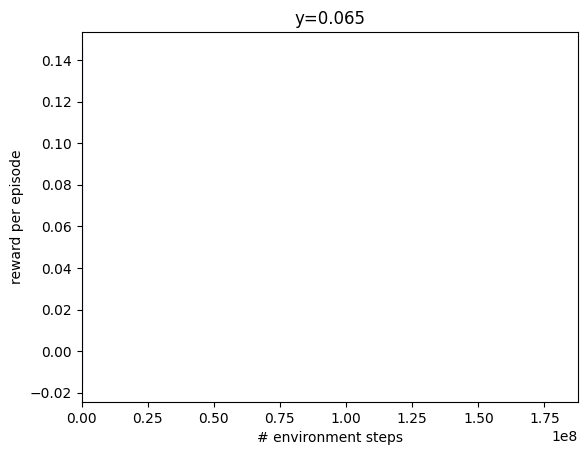

In [ ]:
make_inference_fn, params, metrics = train_fn( 
    environment=env,
    eval_env=registry.load(env_name, config=env_cfg),
    wrap_env_fn=wrapper.wrap_for_brax_training,      # Sollte übernehmbar sein -> evtl. genauer analysieren
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [ ]:
# Ab hier
#@title Rollout and Render
from mujoco_playground._src.gait import draw_joystick_command

env = registry.load(env_name)    # Übernehmbar, wenn Environment registriert ist(s.o.)
eval_env = registry.load(env_name)   
jit_reset = jax.jit(eval_env.reset)
jit_step = jax.jit(eval_env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

rng = jax.random.PRNGKey(1) # Benötigen für Startzustand

rollout = []
modify_scene_fns = []

x_vel = 0.5  #@param {type: "number"}  # Forwärtsgeschwindigkeit muss an unseren Roboter angepasst werden -> zu Beginn übernehmen
y_vel = 0.0  #@param {type: "number"}
yaw_vel = 0.0  #@param {type: "number"} , Rotation
command = jp.array([x_vel, y_vel, yaw_vel])

phase_dt = 2 * jp.pi * eval_env.dt * 1.5 # dt entspricht der Zeitschrittgröße der Simulation
phase = jp.array([0, jp.pi])

for j in range(7):
  print(f"episode {j}")
  state = jit_reset(rng) # Startzustand
  state.info["phase_dt"] = phase_dt
  state.info["phase"] = phase
  for i in range(env_cfg.episode_length):
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng) # Getroffene Entscheidungen (zufallsbasierend)
    state = jit_step(state, ctrl) # Durchführung der Entscheidung/des Schrittes
    if state.done:
      break
    state.info["command"] = command
    rollout.append(state)

    xyz = np.array(state.data.xpos[eval_env.mj_model.body("torso").id]) # state.data.xpos enthält die Position aller Körpers, eval_env.mj_model enthält das Modell der Simualation
    xyz += np.array([0, 0.0, 0]) # ?
    x_axis = state.data.xmat[eval_env._torso_body_id, 0] # x-Wert der Rotationsmatrix wird extrahiert
    yaw = -np.arctan2(x_axis[1], x_axis[0]) # Yaw-Winkel (Drehung um die z-Achse)
    modify_scene_fns.append(
        functools.partial(
            draw_joystick_command,  # Hier muss nichts geändert werden
            cmd=state.info["command"],
            xyz=xyz,
            theta=yaw,
            scl=np.linalg.norm(state.info["command"]),
        )
    )

render_every = 1
fps = 1.0 / eval_env.dt / render_every
print(f"fps: {fps}")
traj = rollout[::render_every] # [start:stop:step]
mod_fns = modify_scene_fns[::render_every]

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = False

frames = eval_env.render(
    traj,
    camera="track",
    scene_option=scene_option,
    width=640*2,
    height=480,
    modify_scene_fns=mod_fns,
)
media.show_video(frames, fps=fps, loop=False)

episode 0
episode 1
episode 2
episode 3
episode 4
episode 5
episode 6
fps: 50.0


  0%|          | 0/719 [00:00<?, ?it/s]


ValueError: The camera "track" does not exist.

In [ ]:
m


NameError: name 'm' is not defined

🙌 Hasta la vista!